# Clustering Project 

## Dataset

The **Programme for International Student Assessment (PISA)** is an OECD survey conducted every three years that measures the competencies of 15-year-old students in mathematics, reading, and science across approximately 80 countries and economies. The 2022 edition is the most recent available.

The dataset provided contains **country-level aggregated data**. Each row represents one country. Variables include weighted mean scores in mathematics, reading, and science, mean socioeconomic index (ESCS), and the proportion of students with access to internet and computer at home.

Your task is to identify groups of countries with similar educational profiles.

Download `pisa2022_country.csv` from Moodle and save it in the same folder as this notebook.

---
---

# Global Education Patterns: Clustering Countries by Academic Performance & Socioeconomic Factors 

## Data Overview

**Purpose:**
Understand the structure and scope of the dataset before applying clustering techniques.

This dataset contains country-level aggregated metrics from PISA 2022, including academic performance (math, reading, science) and socioeconomic indicators (ESCS, internet access, computer access). Each row represents a country.

In [13]:
import pandas as pd
import numpy as np

pisa = pd.read_csv("../data/pisa2022_country (2).csv", index_col=0)

print(pisa.shape)
pisa.head()

(80, 6)


,math,reading,science,escs,pct_internet,pct_computer
ALB,368.352188,358.446138,375.073733,-0.751455,0.897938,0.751878
ARE,431.496902,417.865054,433.102768,0.296656,0.948148,0.943587
ARG,377.967326,400.923353,404.270659,-0.801974,0.894022,0.673932
AUS,486.553774,498.207710,506.435434,0.379367,0.983895,0.962511
AUT,487.593331,480.604566,490.482388,0.069067,0.982417,0.970677


**Insight:**
The dataset includes 80 countries and 6 key variables capturing both educational outcomes and socioeconomic conditions.

This combination allows us to group countries not just by performance, but by underlying factors that may explain differences in educational systems.

----

## Data Quality Check

**Purpose:** 
Ensure the dataset is clean and suitable for clustering by checking data types and missing values.

In [14]:
pisa.info()

print("\nMissing values:")
print(pisa.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, ALB to VNM
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   math          80 non-null     float64
 1   reading       80 non-null     float64
 2   science       80 non-null     float64
 3   escs          80 non-null     float64
 4   pct_internet  80 non-null     float64
 5   pct_computer  80 non-null     float64
dtypes: float64(6)
memory usage: 4.4+ KB

Missing values:
math            0
reading         0
science         0
escs            0
pct_internet    0
pct_computer    0
dtype: int64


**Insight:**
All variables are numeric and there are no missing values across the dataset.

This means the data is immediately suitable for clustering without requiring imputation or extensive preprocessing, allowing us to focus on extracting meaningful patterns.

-----

## Feature Understanding

**Purpose:**
Examine the scale and variation of each feature to understand how countries differ across academic performance and socioeconomic indicators.

In [16]:
pisa.describe()

,math,reading,science,escs,pct_internet,pct_computer
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,437.872526,435.862250,447.415136,-0.363148,0.896578,0.811288
std,58.582174,56.212059,55.958403,0.580593,0.133193,0.177705
min,335.467373,328.762655,346.428566,-2.011323,0.338889,0.221299
25%,389.439068,387.968263,404.006127,-0.734725,0.863091,0.661398
50%,441.347681,439.623216,447.345740,-0.257258,0.959680,0.890989
75%,483.321504,481.097164,492.870278,0.072520,0.984966,0.949843
max,575.016640,544.513549,561.416335,0.521497,0.994137,0.979932


**Insight:**
There is clear variation across countries in both academic performance and socioeconomic measures.

Differences in ESCS, internet access, and test scores suggest that countries may naturally group into clusters with similar educational and economic profiles.

---
---

## Clustering 

## Feature Scaling

**Purpose:**
Standardize features so that all variables contribute equally to the clustering process.

Clustering algorithms like K-Means are distance-based, meaning features with larger scales can dominate the results if not normalized.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pisa)

# check result
X_scaled[:5]

array([[-1.19420214, -1.38590453, -1.30092739, -0.67302983,  0.01027918,
        -0.33642771],
       [-0.1095188 , -0.3221861 , -0.25738168,  1.14360143,  0.38963328,
         0.74918128],
       [-1.02903582, -0.62547671, -0.77587425, -0.7605908 , -0.01930718,
        -0.77781722],
       [ 0.83623369,  1.11610947,  1.06137178,  1.28695828,  0.65971279,
         0.85634474],
       [ 0.85409093,  0.80097769,  0.77448552,  0.7491345 ,  0.64854063,
         0.90258722]])

**Insight:**
All features are now standardized to the same scale, ensuring that variables like test scores and internet access contribute equally to distance calculations.

This step is essential for producing meaningful and balanced clusters.

---

## Optimal Number of Clusters (Elbow Method)

**Purpose:**
Determine the appropriate number of clusters (K) by evaluating how model inertia changes as K increases.

The goal is to find a point where adding more clusters yields diminishing returns.

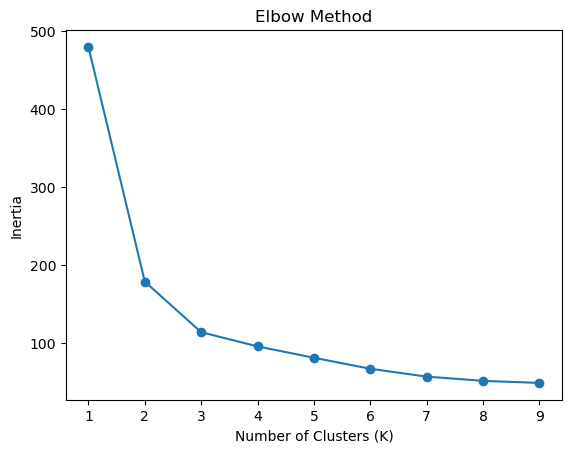

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

**Insight:**
The elbow point appears around K = 3 , where the decrease in inertia begins to level off.

This suggests that grouping countries into approximately 3 clusters captures the main structure of the data without overcomplicating the model.

---

## K-Means Clustering

**Purpose:**
Group countries into clusters based on similarities across academic and socioeconomic features.

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pisa["cluster"] = clusters

pisa.head()

,math,reading,science,escs,pct_internet,pct_computer,cluster
ALB,368.352188,358.446138,375.073733,-0.751455,0.897938,0.751878,2
ARE,431.496902,417.865054,433.102768,0.296656,0.948148,0.943587,2
ARG,377.967326,400.923353,404.270659,-0.801974,0.894022,0.673932,2
AUS,486.553774,498.207710,506.435434,0.379367,0.983895,0.962511,1
AUT,487.593331,480.604566,490.482388,0.069067,0.982417,0.970677,1


**Insight:**
Countries are now grouped into clusters representing similar educational and socioeconomic profiles.

These clusters allow us to identify patterns across countries that may not be obvious through individual variables alone.

---

## Cluster Visualization

**Purposet:**
Visualize clusters to better understand how countries group based on key features.

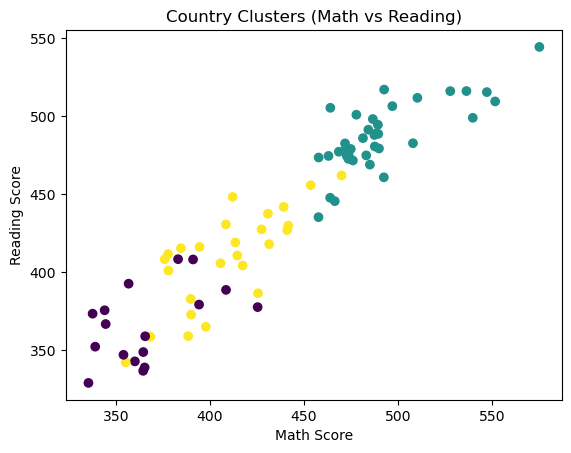

In [20]:
plt.figure()

plt.scatter(pisa["math"], pisa["reading"], c=pisa["cluster"])

plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Country Clusters (Math vs Reading)")

plt.show()

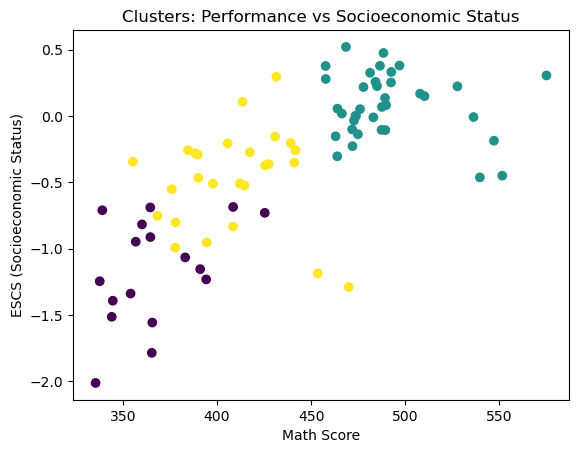

In [21]:
plt.figure()

plt.scatter(pisa["math"], pisa["escs"], c=pisa["cluster"])

plt.xlabel("Math Score")
plt.ylabel("ESCS (Socioeconomic Status)")
plt.title("Clusters: Performance vs Socioeconomic Status")

plt.show()

**Insight:**
Clusters reveal clear groupings of countries with similar academic performance levels.

Higher-performing countries tend to cluster together, while lower-performing countries form separate groups, indicating consistent differences in educational outcomes.

-----
-----

## Cluster Interpretation

**Purpose:**
Analyze the characteristics of each cluster to understand what differentiates groups of countries.

The goal is not just to assign clusters, but to explain what those clusters represent in real-world terms.

In [22]:
pisa.groupby("cluster").mean()

,math,reading,science,escs,pct_internet,pct_computer
cluster,,,,,,
0,366.719336,365.982094,380.587884,-1.163309,0.676030,0.555688
1,490.884537,486.829957,498.739816,0.081865,0.979268,0.948646
2,408.955598,409.022155,418.070910,-0.473254,0.923107,0.782940


**Insight:**

Cluster 1:
Represents high-performing countries with the strongest academic scores across math, reading, and science. These countries also have the highest socioeconomic indicators, including internet and computer access.

Cluster 2:
Represents mid-performing countries with solid academic performance and moderate access to resources. These countries fall between high- and low-performing groups.

Cluster 0:
Represents lower-performing countries with the weakest academic scores and the lowest levels of socioeconomic support, including reduced access to technology.

Overall, the clusters reveal a strong relationship between educational performance and socioeconomic conditions, suggesting that access to resources plays a key role in national education outcomes.

---
---

## Conclusion

**Key Findings:**

This analysis grouped countries into three distinct clusters based on academic performance and socioeconomic factors.

Higher-performing countries consistently showed stronger access to resources such as internet and computers, while lower-performing countries had limited access and lower socioeconomic indicators.

----

**What This Means:**

The results suggest that educational outcomes are not only driven by academic systems, but are strongly linked to underlying socioeconomic conditions.

Countries with better infrastructure and access to technology tend to achieve higher performance levels across all subjects.

----


**Final Insight:**

Clustering reveals clear global patterns in education, highlighting inequality between countries and emphasizing the importance of resource accessibility in shaping educational success.

This type of analysis can help policymakers better understand where to focus efforts to improve education systems worldwide.

----
---